In [1]:
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [3]:
df_train = df_train[df_train['emotion'].isin(['angry', 'happy', 'sad'])]
df_val   = df_val[df_val['emotion'].isin(['angry', 'happy', 'sad'])]
df_test  = df_test[df_test['emotion'].isin(['angry', 'happy', 'sad'])]

In [4]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    return np.mean(mfcc.T, axis=0)  # fixed length vector

In [5]:
def process_dataframe(df):
    X, y = [], []

    for _, row in df.iterrows():
        try:
            features = extract_features(row['path'])
            X.append(features)
            y.append(row['emotion'])
        except:
            continue

    return np.array(X), np.array(y)

In [6]:
X_train, y_train = process_dataframe(df_train)
X_val, y_val     = process_dataframe(df_val)
X_test, y_test   = process_dataframe(df_test)

print(X_train.shape)

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(3084, 40)


In [7]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [9]:
model = SVC(kernel='rbf', C=10)

model.fit(X_train, y_train_enc)

SVC(C=10)

In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test_enc, y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.7485380116959064


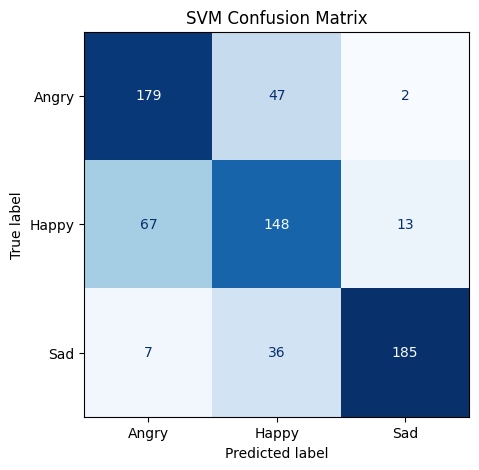

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_enc, y_pred)

labels = ['Angry', 'Happy', 'Sad']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('SVM Confusion Matrix')
plt.savefig('svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test_enc,
    y_pred,
    target_names=['Angry', 'Happy', 'Sad']
)

print(report)

              precision    recall  f1-score   support

       Angry       0.71      0.79      0.74       228
       Happy       0.64      0.65      0.64       228
         Sad       0.93      0.81      0.86       228

    accuracy                           0.75       684
   macro avg       0.76      0.75      0.75       684
weighted avg       0.76      0.75      0.75       684



In [14]:
import pandas as pd

report_dict = classification_report(
    y_test_enc,
    y_pred,
    target_names=['Angry', 'Happy', 'Sad'],
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
print(df_report)

              precision    recall  f1-score     support
Angry          0.707510  0.785088  0.744283  228.000000
Happy          0.640693  0.649123  0.644880  228.000000
Sad            0.925000  0.811404  0.864486  228.000000
accuracy       0.748538  0.748538  0.748538    0.748538
macro avg      0.757734  0.748538  0.751216  684.000000
weighted avg   0.757734  0.748538  0.751216  684.000000


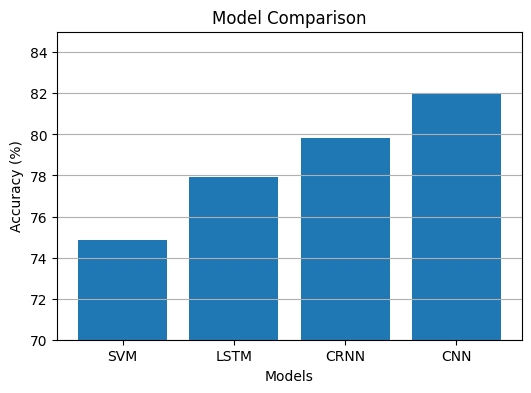

In [15]:
models = ['SVM', 'LSTM', 'CRNN', 'CNN']
accuracies = [74.85, 77.92, 79.82, 82.02]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

plt.ylim(70, 85)
plt.grid(axis='y')

plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()